## Applied Machine Learning Homework 3
### Shane Wang (tsw2134)

#### Note: all discussions will be in the report.

In [1]:
import math
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

import collections

import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import ByteLevel
from tokenizers.decoders import ByteLevel as ByteLevelDecoder

# from sklearn.model_selection import train_test_split

In [2]:
# Seeding for consistency
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Setting chip
if torch.backends.mps.is_available():
    DEVICE = 'mps'
elif torch.cuda.is_available():
    DEVICE = 'cuda'
else:
    DEVICE = 'cpu'

print(f'Using device: {DEVICE}')

Using device: mps


### 1. Data Preparation

#### a. Load Tiny Shakespeare text 

In [3]:
with open('input.txt', 'r') as f:
    raw_text = f.read()

print(raw_text[20000:20050])

the good horse is mine.

MARCIUS:
I'll buy him of 


#### b. Tokenization

Use a `subword-level tokenizer` (e.g., Byte Pair Encoding, WordPiece) to convert text into integer tokens. This captures meaningful text units (like “ing”, “the”, “tion”) rather than single characters, improving both efficiency and coherence. 

Keep the vocabulary size ≤ 500 for lightweight experiments.

In [4]:
# Using Byte Pair Encoding for encoding
VOCAB_SIZE = 500

In [5]:
# Copy input to temporary folder for training purposes
with open('/tmp/corpus.txt', 'w') as f:
    f.write(raw_text)

In [6]:
# Initialize tokenizer (BPE) and specify unknown token replacement
tokenizer = Tokenizer(BPE(unk_token='[UNK]'))
tokenizer.pre_tokenizer = ByteLevel(add_prefix_space=False) # probably unnecessary for Tiny Shakespeare
tokenizer.decoder = ByteLevelDecoder() # uncomment to remove weird whitespace characters in # Testing words cell

trainer = BpeTrainer(
    vocab_size=VOCAB_SIZE,
    special_tokens=['[UNK]', '[PAD]'],
    min_frequency=2
)
tokenizer.train(files=['/tmp/corpus.txt'], trainer=trainer)

# Encode corpus
encoding = tokenizer.encode(raw_text)
token_ids = encoding.ids

ACTUAL_VOCAB_SIZE = tokenizer.get_vocab_size()

In [7]:
# Testing encoding success
print(f'Actual vocab size: {ACTUAL_VOCAB_SIZE}')
print(f'Total tokens after encoding: {len(token_ids):,}')
print(f'Sample tokens (first 20): {token_ids[:20]}')

Actual vocab size: 500
Total tokens after encoding: 516,697
Sample tokens (first 20): [482, 231, 85, 47, 64, 90, 10, 65, 14, 43, 359, 142, 395, 119, 126, 214, 63, 82, 172, 58]


In [8]:
# Testing words
print(tokenizer.decode(token_ids[:20]))
print(tokenizer.id_to_token(482))
print(tokenizer.id_to_token(0))

First Citizen:
Before we proceed any furt
First
[UNK]


#### c. Sequence formatting
Split the tokenized text into overlapping fixed-length sequences (e.g., 50 tokens)
For each sequence:
* Input: first N tokens
* Target: same sequence shifted by one position (next-token prediction)

Example
* Input : [71, 32, 98, 101, 11, 111]
* Target : [32, 98, 101, 11, 111, 114]

In [9]:
SEQUENCE_LENGTH = 50
STRIDE = 15 # This was 1 (too low), which caused issues with training (overfitting)

In [10]:
# def make_sequences(ids, seq_len, stride):
#     inputs, targets = [], []
#     for start in range(0, len(ids) - seq_len, stride):
#         chunk = ids[start : start + seq_len + 1]
#         inputs.append(chunk[:-1])
#         targets.append(chunk[1:]) 
#     return inputs, targets

# all_inputs, all_targets = make_sequences(token_ids, SEQUENCE_LENGTH, STRIDE)

# Make sequences as input, output (target) pairs
def make_sequences(ids, seq_len, stride):
    ids_tensor = torch.tensor(ids, dtype=torch.long)
    inputs, targets = [], []
    for start in range(0, len(ids_tensor) - seq_len, stride):
        inputs.append(ids_tensor[start : start + seq_len])
        targets.append(ids_tensor[start + 1 : start + seq_len + 1])
    return torch.stack(inputs), torch.stack(targets)

all_inputs, all_targets = make_sequences(token_ids, SEQUENCE_LENGTH, STRIDE)

print(f"Input shape: {all_inputs.shape}")
print(f"Target shape: {all_targets.shape}")

Input shape: torch.Size([34444, 50])
Target shape: torch.Size([34444, 50])


#### d. Data split
Use 80% for training and 20% for validation, no test set is needed this time

In [11]:
# # The following causes data leakage:
# all_inputs, all_targets = make_sequences(token_ids, SEQ_LEN, STRIDE)

# train_inputs, val_inputs, train_targets, val_targets = train_test_split(
#     all_inputs, all_targets,
#     test_size=0.2,
#     random_state=SEED,
#     shuffle=True
# )

# print(f'Training sequences: {len(train_inputs):,}')
# print(f'Validation sequences: {len(val_inputs):,}')

split_index = int(len(token_ids) * 0.8)

train_ids = token_ids[:split_index]
val_ids = token_ids[split_index:]

train_inputs, train_targets = make_sequences(train_ids, SEQUENCE_LENGTH, STRIDE)
val_inputs, val_targets = make_sequences(val_ids, SEQUENCE_LENGTH, STRIDE)

print(f'Training sequences: {len(train_inputs):,}')
print(f'Validation sequences: {len(val_inputs):,}')
print(f"Training shape: {train_inputs.shape}")
print(f"Validation shape: {val_inputs.shape}")

Training sequences: 27,554
Validation sequences: 6,886
Training shape: torch.Size([27554, 50])
Validation shape: torch.Size([6886, 50])


#### e. Token embedding
Use `nn.Embedding` for tokens and add positional encodings

In [12]:
D_MODEL = 128  # embedding / hidden dimension

token_embedding = nn.Embedding(ACTUAL_VOCAB_SIZE, D_MODEL).to(DEVICE)

# Sanity check
sample_input = train_inputs[:4].to(DEVICE) # (4, 50)
sample_output = token_embedding(sample_input) # (4, 50, 128)

print(f"Input shape: {sample_input.shape}")
print(f"Output shape: {sample_output.shape}")

Input shape: torch.Size([4, 50])
Output shape: torch.Size([4, 50, 128])


### 2. Implement a Tiny Transformer
Build a minimal Transformer-based language model including:
* Positional encoding (sinusoidal or RoPE if you want more challenges)
* Self-attention module
* Apply a causal mask to prevent the model from attending to future tokens
* Feed-forward network with residual connections and RMSnorm

Train it using `cross-entropy loss` for next-token prediction

#### a. Positional Encoding

In [13]:
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_len):
        super().__init__()
        positional_encoding = torch.zeros(max_seq_len, d_model) # (Time (max sequence length), Dimension (d_model))
        position = torch.arange(0, max_seq_len).unsqueeze(1).float() # (Time (max sequence length), 1)

        # a^b = exp(b * ln(a))
        # a = 10000, b = -2i / d_model
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        positional_encoding[:, 0::2] = torch.sin(position * div_term) # even indices
        positional_encoding[:, 1::2] = torch.cos(position * div_term) # odd indices
        self.register_buffer('positional_encoding', positional_encoding.unsqueeze(0)) # (1, Time (max sequence length), Dimension (d_model))

    def forward(self, x):
        return x + self.positional_encoding[:, :x.size(1)] # broadcast over batch

#### b. Self Attention and c. Causal Mask

In [14]:
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

        self.qkv_proj = nn.Linear(d_model, 3 * d_model, bias=False) # linear projection of query, key, value
        self.out_proj = nn.Linear(d_model, d_model, bias=False)

        # Stored after each forward pass - used for attention heatmaps
        self.attn_weights = None # (B, H, T, T)

    def forward(self, x):
        batch_size, seq_len, d_model = x.shape # B, T, D

        # Project to Q, K, V in one shot then split
        queries, keys, values = self.qkv_proj(x).split(d_model, dim=-1) # each (B, T, D)

        # Reshape into heads: (B, H, T, head_dim)
        def split_into_heads(tensor):
            return tensor.view(batch_size, seq_len, self.n_heads, self.head_dim).transpose(1, 2)

        queries, keys, values = split_into_heads(queries), split_into_heads(keys), split_into_heads(values)

        # Scaled dot-product scores
        scale  = math.sqrt(self.head_dim)
        scores = (queries @ keys.transpose(-2, -1)) / scale # (B, H, T, T)

        # Causal mask: make upper triangle -inf so softmax is 0
        causal_mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device), diagonal=1).bool()
        scores = scores.masked_fill(causal_mask, float('-inf'))

        attn = F.softmax(scores, dim=-1)
        self.attn_weights = attn.detach() # save for viz

        out = (attn @ values).transpose(1, 2).contiguous().view(batch_size, seq_len, d_model)
        return self.out_proj(out)

#### d. FFN with Residual Connections and RMSnorm

In [15]:
# Root mean square normalization
class RMSNorm(nn.Module):
    def __init__(self, d_model, eps=1e-8):
        super().__init__()
        self.scale = nn.Parameter(torch.ones(d_model))
        self.eps = eps # epsilon, tiny value to prevent divide by 0

    def forward(self, x):
        rms = x.pow(2).mean(-1, keepdim=True).add(self.eps).sqrt()
        return self.scale * x / rms

class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, ffn_mult=4):
        super().__init__()
        self.norm1 = RMSNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads)
        self.norm2 = RMSNorm(d_model)
        # Feed forward neural network:
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ffn_mult * d_model, bias=False),
            nn.GELU(),
            nn.Linear(ffn_mult * d_model, d_model, bias=False),
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x)) # pre-norm + residual
        x = x + self.ffn(self.norm2(x)) # pre-norm + residual
        return x

In [16]:
class TinyTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, seq_len):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_enc = SinusoidalPositionalEncoding(d_model, max_seq_len=seq_len)
        self.blocks = nn.ModuleList(
            [TransformerBlock(d_model, n_heads) for _ in range(n_layers)]
        )
        self.norm = RMSNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, x):
        x = self.pos_enc(self.token_emb(x))
        for block in self.blocks:
            x = block(x)
        return self.head(self.norm(x)) # (B, T, vocab)

    def get_attention_weights(self):
        """Returns list of attn weight tensors for heatmaps"""
        return [block.attn.attn_weights for block in self.blocks]

#### e. Training with `Cross-Entropy Loss` for next token prediction

In [17]:
# Hyperparameters
N_HEADS = 4 # number of heads
N_LAYERS = 2 # number of layers
BATCH_SIZE = 128 # 2^7, just so happened to also be embedding size
N_EPOCHS = 10 # number of epochs
LR = 3e-4 # learning rate

# DataLoaders
class TokenDataset(Dataset):
    def __init__(self, inputs, targets):
        self.inputs = inputs
        self.targets = targets
    def __len__(self):
        return len(self.inputs)
    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx]

train_loader = DataLoader(TokenDataset(train_inputs, train_targets), batch_size=BATCH_SIZE, shuffle=True, pin_memory=False)
val_loader = DataLoader(TokenDataset(val_inputs, val_targets), batch_size=BATCH_SIZE, shuffle=False, pin_memory=False)

In [18]:
# Model + optimizer
model = TinyTransformer(ACTUAL_VOCAB_SIZE, D_MODEL, N_HEADS, N_LAYERS, SEQUENCE_LENGTH).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 521,856


In [19]:
# Training
train_losses = [] # mean cross-entropy per epoch
val_losses = [] # mean cross-entropy per epoch
val_ppls = [] # perplexity per epoch

for epoch in range(N_EPOCHS):
    model.train()
    running = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb) # (B, T, V)
        loss = F.cross_entropy(logits.view(-1, ACTUAL_VOCAB_SIZE), yb.view(-1))
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # stability
        optimizer.step()
        running += loss.item()
    train_loss = running / len(train_loader)
    train_losses.append(train_loss)

    # Validate
    model.eval()
    running = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss   = F.cross_entropy(logits.view(-1, ACTUAL_VOCAB_SIZE), yb.view(-1))
            running += loss.item()
    val_loss = running / len(val_loader)
    val_ppl  = math.exp(val_loss)
    val_losses.append(val_loss)
    val_ppls.append(val_ppl)

    print(f"Epoch {epoch+1}/{N_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val PPL: {val_ppl:.2f}")

# Final Perplexity
final_val_perplexity = val_ppls[-1]
print(f"\nFinal Validation Perplexity: {final_val_perplexity:.2f}")

Epoch 1/10 | Train Loss: 4.9332 | Val Loss: 4.3492 | Val PPL: 77.42
Epoch 2/10 | Train Loss: 3.9123 | Val Loss: 3.9879 | Val PPL: 53.94
Epoch 3/10 | Train Loss: 3.6077 | Val Loss: 3.8459 | Val PPL: 46.80
Epoch 4/10 | Train Loss: 3.4234 | Val Loss: 3.7514 | Val PPL: 42.58
Epoch 5/10 | Train Loss: 3.2831 | Val Loss: 3.6881 | Val PPL: 39.97
Epoch 6/10 | Train Loss: 3.1716 | Val Loss: 3.6324 | Val PPL: 37.81
Epoch 7/10 | Train Loss: 3.0817 | Val Loss: 3.5827 | Val PPL: 35.97
Epoch 8/10 | Train Loss: 3.0093 | Val Loss: 3.5593 | Val PPL: 35.14
Epoch 9/10 | Train Loss: 2.9486 | Val Loss: 3.5426 | Val PPL: 34.56
Epoch 10/10 | Train Loss: 2.8979 | Val Loss: 3.5226 | Val PPL: 33.87

Final Validation Perplexity: 33.87


### Visualization & Interpretation
Note: most of these are boilerplate code that's generated by Claude. Other than the "Optionally, include sample generations to qualitatively assess model fluency and coherence", everything else is trivial.
#### Plot training and validation loss curves over epochs

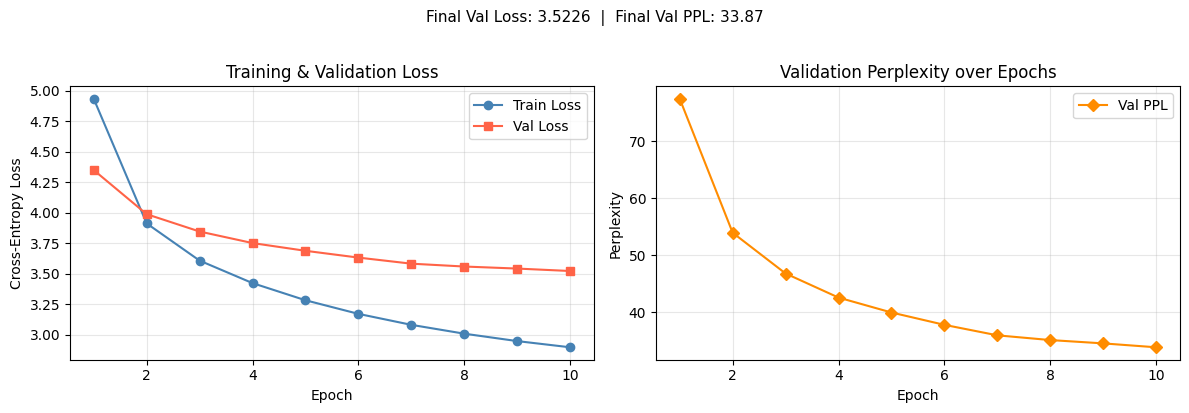

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, N_EPOCHS + 1)

# Loss curves
axes[0].plot(epochs, train_losses, marker='o', label='Train Loss', color='steelblue')
axes[0].plot(epochs, val_losses,   marker='s', label='Val Loss',   color='tomato')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Perplexity curve
axes[1].plot(epochs, val_ppls, marker='D', color='darkorange', label='Val PPL')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexity')
axes[1].set_title('Validation Perplexity over Epochs')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(f'Final Val Loss: {val_losses[-1]:.4f}  |  Final Val PPL: {val_ppls[-1]:.2f}',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

#### Plot attention heatmaps for sample sequences to visualize which tokens attend to which

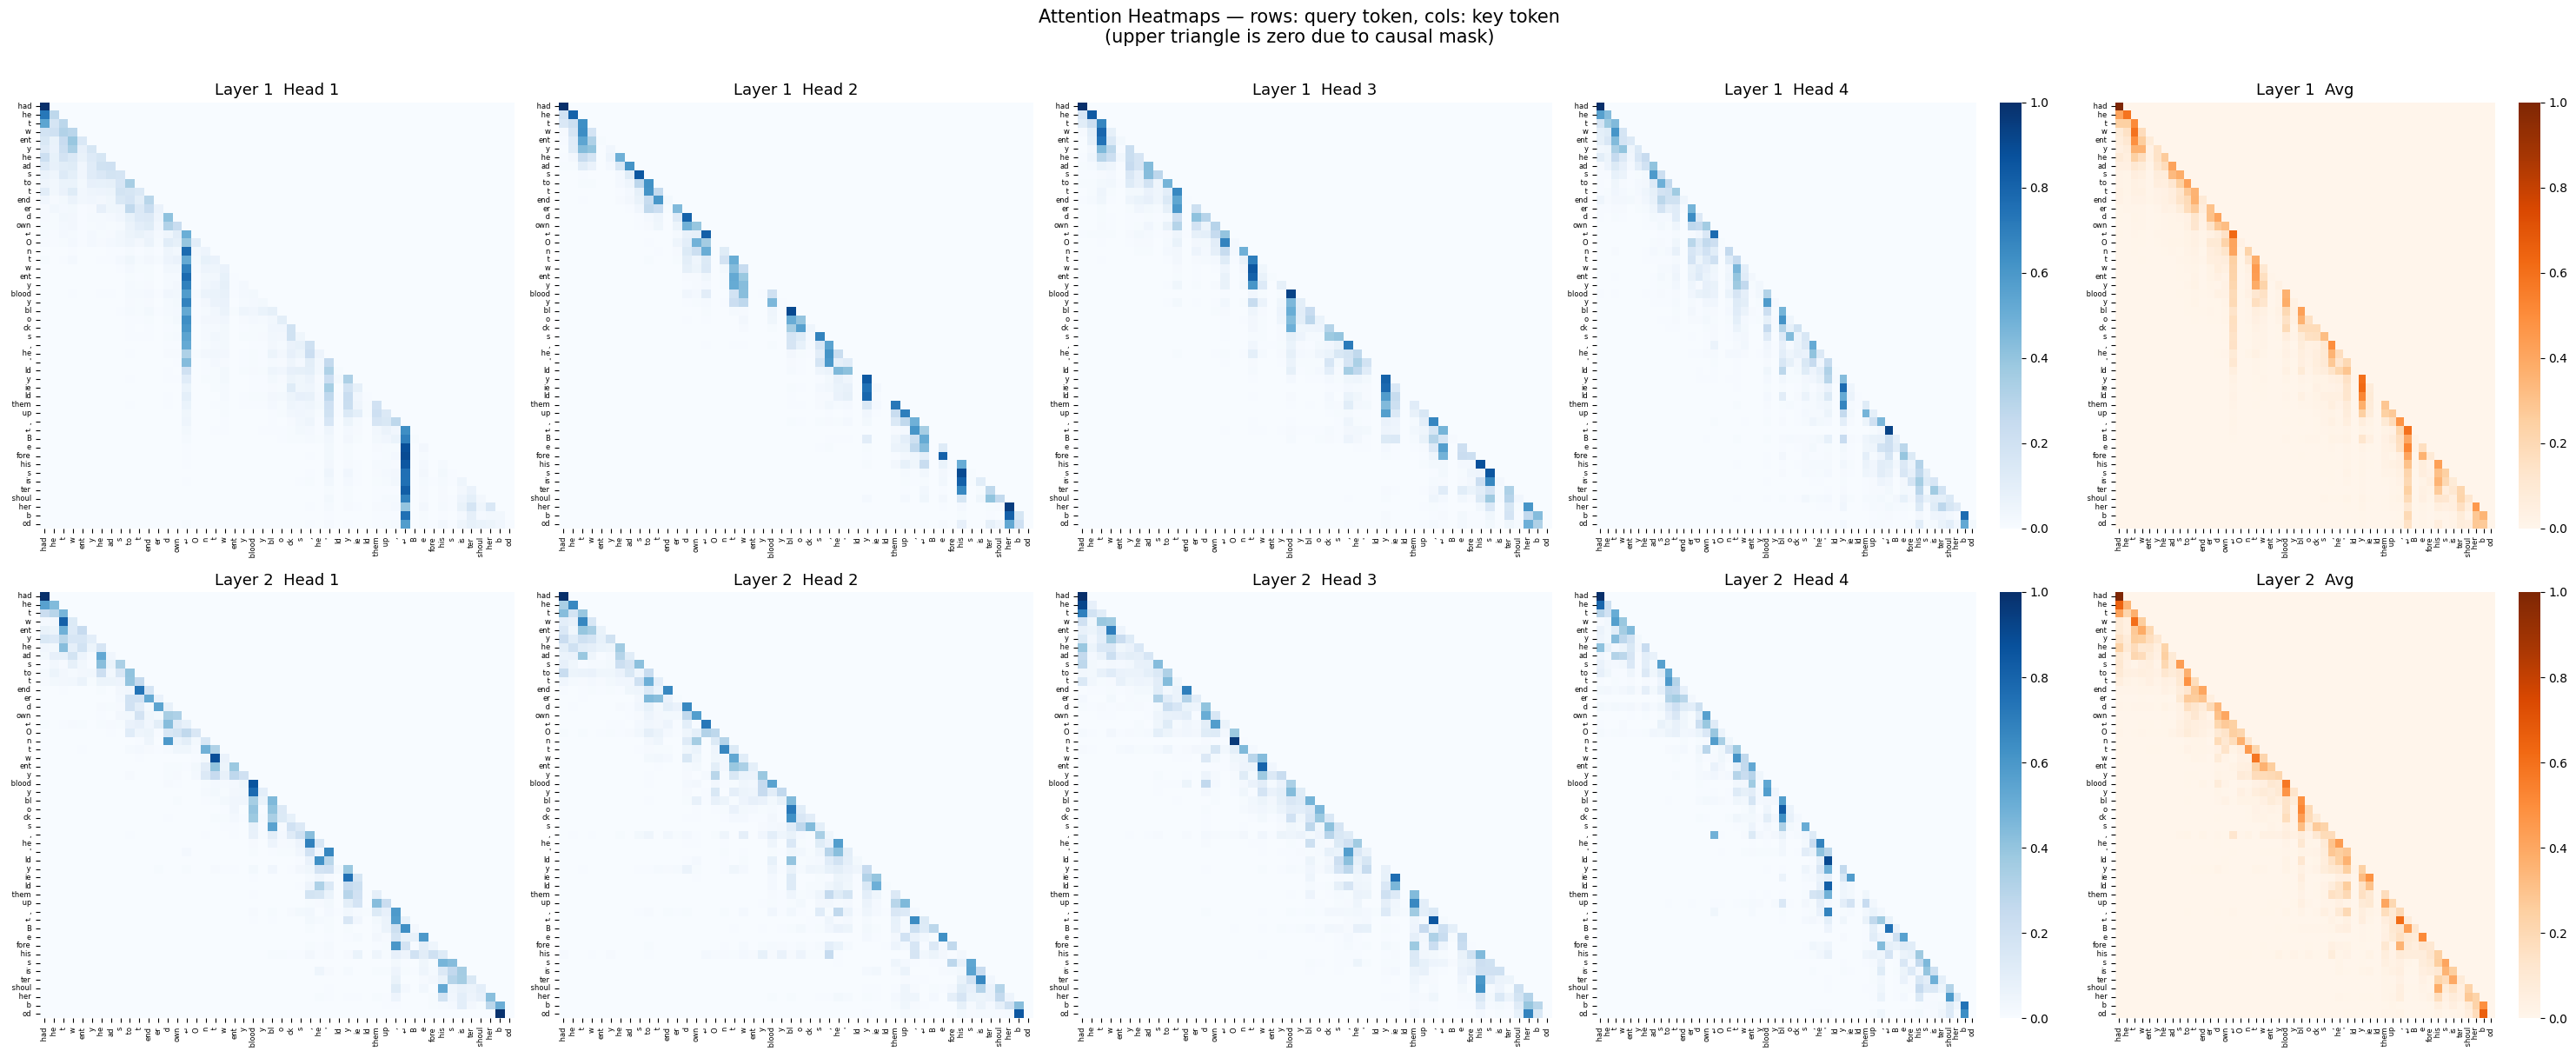

In [21]:
def get_token_labels(token_ids_1d, tokenizer):
    """Decode each token id to a short readable label, stripping BPE whitespace markers."""
    labels = []
    for tid in token_ids_1d:
        tok = tokenizer.id_to_token(int(tid)) or str(int(tid))
        tok = tok.replace("Ġ", " ").replace("Ċ", "↵")
        labels.append(tok)
    return labels

def plot_attention_heatmaps(model, tokenizer, sample_input, device, max_label_len=6):
    """
    Run one forward pass on `sample_input` (1-D tensor of token ids, length T),
    then plot per-head attention matrices for every Transformer layer.
    """
    model.eval()
    x = sample_input.unsqueeze(0).to(device)      # (1, T)

    with torch.no_grad():
        _ = model(x)                               # populates attn_weights in each block

    all_weights = model.get_attention_weights()    # list of (1, H, T, T)
    labels = get_token_labels(sample_input, tokenizer)
    labels = [lbl[:max_label_len] for lbl in labels]

    n_layers = len(all_weights)
    n_heads  = all_weights[0].shape[1]

    fig, axes = plt.subplots(n_layers, n_heads + 1,
                             figsize=(6 * (n_heads + 1), 6 * n_layers))
    if n_layers == 1:
        axes = axes[np.newaxis, :]

    for layer_idx, weights in enumerate(all_weights):
        w     = weights[0].cpu().numpy()           # (H, T, T)
        avg_w = w.mean(axis=0)                     # (T, T) – average over heads

        for head_idx in range(n_heads):
            ax = axes[layer_idx, head_idx]
            sns.heatmap(w[head_idx], ax=ax, cmap='Blues', vmin=0, vmax=1,
                        cbar=(head_idx == n_heads - 1),
                        xticklabels=labels,
                        yticklabels=labels)
            ax.set_title(f'Layer {layer_idx+1}  Head {head_idx+1}', fontsize=13)
            ax.tick_params(axis='x', rotation=90, labelsize=6)
            ax.tick_params(axis='y', rotation=0,  labelsize=6)

        # Averaged-head column
        ax_avg = axes[layer_idx, n_heads]
        sns.heatmap(avg_w, ax=ax_avg, cmap='Oranges', vmin=0, vmax=avg_w.max(),
                    cbar=True,
                    xticklabels=labels,
                    yticklabels=labels)
        ax_avg.set_title(f'Layer {layer_idx+1}  Avg', fontsize=13)
        ax_avg.tick_params(axis='x', rotation=90, labelsize=6)
        ax_avg.tick_params(axis='y', rotation=0,  labelsize=6)

    fig.suptitle(
        'Attention Heatmaps — rows: query token, cols: key token\n'
        '(upper triangle is zero due to causal mask)',
        fontsize=15, y=1.01
    )
    plt.tight_layout()
    plt.savefig('attention_heatmaps.png', dpi=150, bbox_inches='tight')
    plt.show()

# Pick a sample from the validation set
SAMPLE_IDX = 0
sample_seq = val_inputs[SAMPLE_IDX]               # (50,)
plot_attention_heatmaps(model, tokenizer, sample_seq, DEVICE)

#### Report Perplexity (PPL) on the validation set as the main evaluation metric - lower is better

In [22]:
print("=" * 45)
print(f"  Final Validation Perplexity (PPL): {val_ppls[-1]:.2f}")
print(f"  (PPL = exp(val_loss) = exp({val_losses[-1]:.4f}))")
print("=" * 45)

  Final Validation Perplexity (PPL): 33.87
  (PPL = exp(val_loss) = exp(3.5226))


#### Optionally, include sample generations to qualitatively assess model fluency and coherence

In [23]:
@torch.no_grad()
def generate(model, tokenizer, prompt: str, max_new_tokens: int = 80,
             temperature: float = 0.9, top_k: int = 40, device: str = 'cpu'):
    """
    Greedy / top-k sampled generation from a text prompt.
    """
    model.eval()
    ids = tokenizer.encode(prompt).ids
    ctx = torch.tensor(ids, dtype=torch.long, device=device).unsqueeze(0)   # (1, T)

    for _ in range(max_new_tokens):
        # Crop context to model's max sequence length
        ctx_crop = ctx[:, -SEQUENCE_LENGTH:]
        logits = model(ctx_crop)[:, -1, :]          # (1, vocab)

        # Temperature scaling + top-k filtering
        logits = logits / temperature
        if top_k is not None:
            top_vals, _ = torch.topk(logits, top_k)
            logits[logits < top_vals[:, -1:]] = float('-inf')

        probs   = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)                   # (1, 1)
        ctx     = torch.cat([ctx, next_id], dim=1)

    generated_ids = ctx[0, len(ids):].tolist()
    return prompt + tokenizer.decode(generated_ids)

prompt = "ROMEO:\nWhat light through yonder"
generated_text = generate(model, tokenizer, prompt, max_new_tokens=100,
                           temperature=0.9, top_k=40, device=DEVICE)
print("\n── Generated Text ──")
print(generated_text)

prompt = "MACBETH:\nO Lady"
generated_text = generate(model, tokenizer, prompt, max_new_tokens=100,
                           temperature=0.9, top_k=40, device=DEVICE)
print("\n── Generated Text ──")
print(generated_text)


── Generated Text ──
ROMEO:
What light through yonder-disty watch it?

First Servingman:
I'll tell you know the vantagglination will not
to your accuse
Tutation.

VOLUMBERLAND:

Second Murderer:
I fooler to Lady Pristy and chairglects.



── Generated Text ──
MACBETH:
O Lady Cloud to apparent me
In easte, bold, and not the suppo: as I'll be the king.
Shall Jeeter's villain!

Shepeak for you, a pale, and do not
For 'tis you had a moxtendspation, but straight
And two many'd, and callad
